**Autor:** Andrés Alejandro Rodríguez Lozano  
**Portafolio:** Portafolio de Andrés Alejandro Rodríguez Lozano

# Capítulo 8 — Matriz de correlación

$$\rho_{ij} = \frac{\mathrm{Cov}(R_i,R_j)}{\sigma_i\sigma_j}$$


       SPYG   SMH  BRK-B  IEMG   VTI
SPYG   1.00  0.81   0.48  0.65  0.94
SMH    0.81  1.00   0.30  0.70  0.77
BRK-B  0.48  0.30   1.00  0.38  0.61
IEMG   0.65  0.70   0.38  1.00  0.71
VTI    0.94  0.77   0.61  0.71  1.00


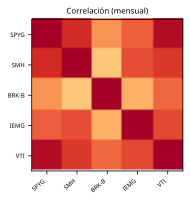

In [ ]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
%config InlineBackend.figure_formats = ['svg']
ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT / 'src'))
import portfolio_utils as pu
import seaborn as sns
daily = pd.read_csv(ROOT/'data'/'precios_ajustados_diarios.csv', index_col=0, parse_dates=True)
monthly = pu.to_month_end(daily)
rets = monthly.pct_change().loc['2016-01-31':'2026-09-30']
tickers = list(pu.CURRENT_WEIGHTS)
corr = rets[tickers].corr()
print(corr.round(2))
fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title('Correlación mensual')
plt.tight_layout(); plt.show()


In [ ]:
pairs=[]
for i,a in enumerate(tickers):
    for b in tickers[i+1:]:
        pairs.append((a,b,float(corr.loc[a,b])))
pairs = sorted(pairs, key=lambda x: x[2], reverse=True)
print('Más correlacionados:')
for a,b,r in pairs[:3]: print(f'  {a}-{b}: {r:.3f}')
print('Menos correlacionados:')
for a,b,r in pairs[-3:]: print(f'  {a}-{b}: {r:.3f}')


Más correlacionados:
  SPYG-VTI: 0.942
  SPYG-SMH: 0.814
  SMH-VTI: 0.771
Menos correlacionados:
  SPYG-BRK-B: 0.479
  BRK-B-IEMG: 0.379
  SMH-BRK-B: 0.304


## Conclusiones
1. Diversificación real del núcleo viene sobre todo de IEMG y BRK-B.

## Ejercicios
1. Correlaciones en ventanas de 36 meses.
2. Añade TLT hipotéticamente.
3. Compara 2020 vs 2022.
